In [ ]:
import kagglehub


path = kagglehub.dataset_download("saurograndi/airplane-crashes-since-1908")
print("Path to dataset files:", path)

100%|██████████| 564k/564k [00:00<00:00, 67.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/saurograndi/airplane-crashes-since-1908/versions/4


In [ ]:
import os


for file in os.listdir(path):
  print(file)

Airplane_Crashes_and_Fatalities_Since_1908.csv


In [ ]:
import pandas as pd

csv_path = os.path.join(path, "Airplane_Crashes_and_Fatalities_Since_1908.csv")
df = pd.read_csv(csv_path)
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [ ]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")


Rows: 5268, Columns: 13


In [ ]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


## Q4:Missing Data Treatment

- **Aboard, Fatalities** (22, 12 missing): impute with **median** — crash
  sizes are skewed by a few huge disasters, so median beats mean.
- **Ground** (22 missing): fill with **0** — a blank likely means no ground
  deaths, not lost data.
- **Location, Operator, Type, Registration, cn/ln, Summary** (20–1228
  missing): fill with **"Unknown"** — gaps are too small to justify
  dropping rows, and there's no reliable way to infer these values.
- **Route** (1707 missing, 32%): fill with **"Unknown"** — not used in
  core calculations, so dropping a third of the data isn't worth it.
- **Time** (2219 missing, 42%): leave as **missing/flagged** — not used
  in any required analysis, and guessing a time for 42% of rows would be
  fabrication.   
- **Flight #** (4199 missing, 80%): **drop the column** — mostly missing
  because older crashes predate flight-numbering conventions; not usable.  


In [ ]:
fatality_locations = df[['Date','Location','Aboard','Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
max_fatalities_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(max_fatalities_row)

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object


In [ ]:
fatality_locations['Survivors'] = fatality_locations['Aboard'] - fatality_locations['Fatalities']
print(fatality_locations[['Aboard', 'Fatalities','Survivors']].describe())

zero_fatalities = fatality_locations[fatality_locations['Fatalities'] == 0]
print(f"\nNumber of crashes with zero fatalities: {len(zero_fatalities)}")


            Aboard   Fatalities    Survivors
count  5246.000000  5256.000000  5246.000000
mean     27.554518    20.068303     7.471026
std      43.076711    33.199952    28.144659
min       0.000000     0.000000     0.000000
25%       5.000000     3.000000     0.000000
50%      13.000000     9.000000     0.000000
75%      30.000000    23.000000     2.000000
max     644.000000   583.000000   516.000000

Number of crashes with zero fatalities: 58


In [ ]:
split_location = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)
fatality_locations['Region'] = split_location[0].str.strip()
fatality_locations['State/Country'] = split_location[1].str.strip()
fatality_locations[['Location','Region', 'State/Country']].head(10)

,Location,Region,State/Country
0,"Fort Myer, Virginia",Fort Myer,Virginia
1,"AtlantiCity, New Jersey",AtlantiCity,New Jersey
2,"Victoria, British Columbia, Canada","Victoria, British Columbia",Canada
3,Over the North Sea,Over the North Sea,None
4,"Near Johannisthal, Germany",Near Johannisthal,Germany
5,"Tienen, Belgium",Tienen,Belgium
6,"Off Cuxhaven, Germany",Off Cuxhaven,Germany
7,"Near Jambol, Bulgeria",Near Jambol,Bulgeria
8,"Billericay, England",Billericay,England
9,"Potters Bar, England",Potters Bar,England


In [ ]:
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100_fatalities.head(10)

,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland
3240,08/19/1980,"Near Riyadh, Saudi Arabia",301.0,301.0,0.0,Near Riyadh,Saudi Arabia
3775,07/03/1988,"Over the Persian Gulf, near Bandar Abbas, Iran",290.0,290.0,0.0,"Over the Persian Gulf, near Bandar Abbas",Iran
4916,02/19/2003,"Near Shahdad, Iran",275.0,275.0,0.0,Near Shahdad,Iran
3137,05/25/1979,"Chicago O'Hare, Illinois",271.0,271.0,0.0,Chicago O'Hare,Illinois
3436,09/01/1983,"Near Sakhalin Island, Russia",269.0,269.0,0.0,Near Sakhalin Island,Russia


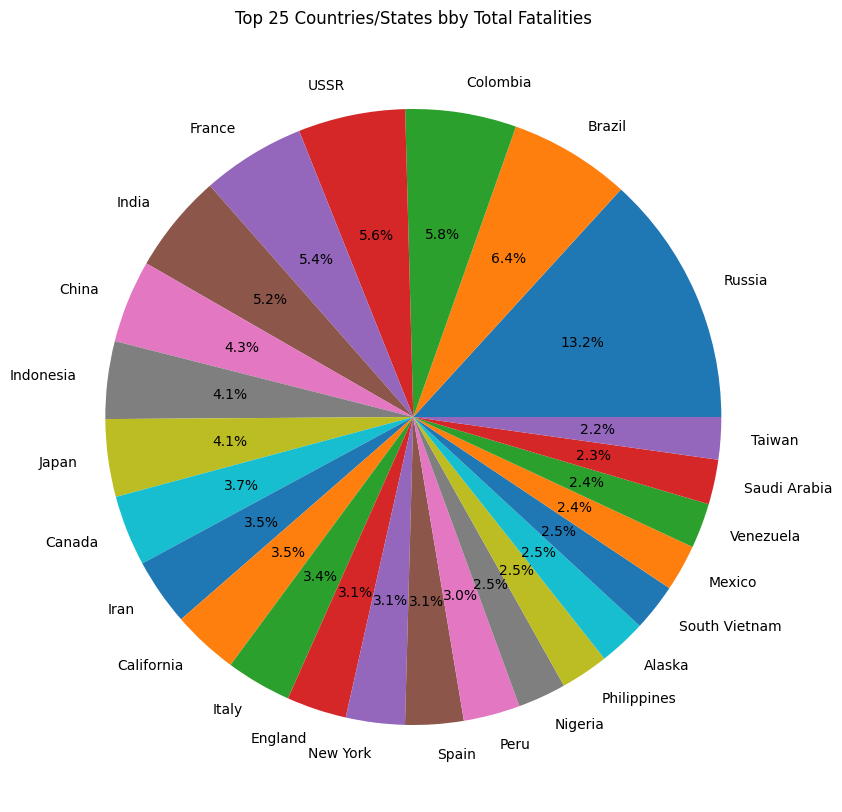

In [ ]:
import matplotlib.pyplot as plt
top_25_by_country = (
    fatality_locations.groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)

)

plt.figure(figsize=(10, 10))
plt.pie(top_25_by_country, labels=top_25_by_country.index, autopct='%1.1f%%')
plt.title('Top 25 Countries/States bby Total Fatalities')
plt.show()